# 💼 Trabalho Final — Alocação de Desenvolvedores em Projetos
**Pesquisa Operacional e Otimização em IA** — MBA em Ciência de Dados (UNIFOR)

Prof. Mafra | mafra@verboo.ai

---

O departamento de **IA** está organizando a alocação de sua equipe de desenvolvimento para o próximo ciclo. São **7 desenvolvedores** e **5 projetos** ativos, e o objetivo é encontrar a alocação que **maximize a produtividade total** da equipe, respeitando um conjunto de restrições operacionais.

In [1]:
!pip install pulp -q
from pulp import *


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


---
## Contexto

A equipe é composta por **7 desenvolvedores**: Ana, Bruno, Carlos, Diego, Eduardo, Fábio e Gabriel. Destes, **Ana, Bruno e Carlos são seniores**; os demais são juniores.

Os projetos ativos são:

| Projeto | Tipo | Observação |
|---------|------|------------|
| **Orion** | BAU (manutenção) | — |
| **Lyra** | BAU (manutenção) | — |
| **Hydra** | Desenvolvimento | Requer ao menos 2 devs |
| **Vela** | Desenvolvimento | — |
| **Cygnus** | Desenvolvimento | Iniciado por Ana |

Projetos do tipo **BAU** são de manutenção contínua; projetos de **desenvolvimento** exigem foco total — um desenvolvedor não pode estar em dois projetos de desenvolvimento ao mesmo tempo.

---
## Variáveis de Decisão

Defina uma variável binária para cada par (desenvolvedor, projeto):

$$x_{d,p} \in \{0, 1\} \quad \forall\, d \in D,\; p \in P$$

onde $x_{d,p} = 1$ indica que o desenvolvedor $d$ está alocado ao projeto $p$.

---
## Função Objetivo

Maximizar a produtividade total da alocação:

$$\text{Maximizar} \quad \sum_{d \in D} \sum_{p \in P} \text{prod}_{d,p} \cdot x_{d,p}$$

onde $\text{prod}_{d,p}$ é a pontuação de compatibilidade do desenvolvedor $d$ com o projeto $p$ (valores de 1 a 10).

---
## Restrições

1. **Binariedade:** $x_{d,p} \in \{0,1\}$ para todo $d \in D$, $p \in P$.

2. **Exclusividade em desenvolvimento:** nenhum dev pode estar em mais de um projeto de desenvolvimento simultaneamente:
$$x_{d,\text{Hydra}} + x_{d,\text{Vela}} + x_{d,\text{Cygnus}} \leq 1 \quad \forall\, d \in D$$

3. **Sênior obrigatório em desenvolvimento:** cada projeto de desenvolvimento deve ter pelo menos um dev sênior:
$$\sum_{s \in \{\text{Ana, Bruno, Carlos}\}} x_{s,p} \geq 1 \quad \forall\, p \in \{\text{Hydra, Vela, Cygnus}\}$$

4. **Tamanho mínimo do Hydra:** o projeto Hydra deve ter pelo menos 2 desenvolvedores:
$$\sum_{d \in D} x_{d,\text{Hydra}} \geq 2$$

5. **Iniciador do Cygnus:** Ana deve estar alocada ao Cygnus (ela iniciou o projeto):
$$x_{\text{Ana},\text{Cygnus}} = 1$$

6. **Limites por projeto:** cada projeto deve ter entre $\min_p$ e $\max_p$ desenvolvedores alocados:
$$\min_p \leq \sum_{d \in D} x_{d,p} \leq \max_p \quad \forall\, p \in P$$

---
## Dados do Problema

### Desenvolvedores e senioridade

| Desenvolvedor | Nível |
|---------------|-------|
| Ana | Sênior |
| Bruno | Sênior |
| Carlos | Sênior |
| Diego | Júnior |
| Eduardo | Júnior |
| Fábio | Júnior |
| Gabriel | Júnior |

### Limites de alocação por projeto

| Projeto | Mín. devs | Máx. devs |
|---------|-----------|----------|
| Orion | 1 | 3 |
| Lyra | 1 | 2 |
| Hydra | 2 | 4 |
| Vela | 1 | 3 |
| Cygnus | 2 | 3 |

### Matriz de produtividade $\text{prod}_{d,p}$ (pontuação de 1 a 10)

| Dev \ Projeto | Orion | Lyra | Hydra | Vela | Cygnus |
|---------------|-------|------|-------|------|--------|
| Ana     | 5 | 10 | 7 | 8  | 10 |
| Bruno   | 4 | 6  | 10 | 7 | 5  |
| Carlos  | 8 | 6  | 8 | 10 | 6  |
| Diego   | 5 | 6  | 7 | 5  | 3  |
| Eduardo | 6 | 7  | 5 | 8  | 3  |
| Fábio   | 7 | 8  | 8 | 6  | 4  |
| Gabriel | 4 | 6  | 3 | 6  | 8  |

---

In [2]:
prob = LpProblem("Alocacao_Devs", LpMaximize)

devs = ["Ana", "Bruno", "Carlos", "Diego", "Eduardo", "Fábio", "Gabriel"]
projetos = ["Orion", "Lyra", "Hydra", "Vela", "Cygnus"]
dev_proj = ["Hydra", "Vela", "Cygnus"]
seniors = ["Ana", "Bruno", "Carlos"]

prod = {
    "Ana":     {"Orion": 5, "Lyra": 10, "Hydra": 7,  "Vela": 8,  "Cygnus": 10},
    "Bruno":   {"Orion": 4, "Lyra": 6,  "Hydra": 10, "Vela": 7,  "Cygnus": 5},
    "Carlos":  {"Orion": 8, "Lyra": 6,  "Hydra": 8,  "Vela": 10, "Cygnus": 6},
    "Diego":   {"Orion": 5, "Lyra": 6,  "Hydra": 7,  "Vela": 5,  "Cygnus": 3},
    "Eduardo": {"Orion": 6, "Lyra": 7,  "Hydra": 5,  "Vela": 8,  "Cygnus": 3},
    "Fábio":   {"Orion": 7, "Lyra": 8,  "Hydra": 8,  "Vela": 6,  "Cygnus": 4},
    "Gabriel": {"Orion": 4, "Lyra": 6,  "Hydra": 3,  "Vela": 6,  "Cygnus": 8},
}

limites = {
    "Orion":  (1, 3),
    "Lyra":   (1, 2),
    "Hydra":  (2, 4),
    "Vela":   (1, 3),
    "Cygnus": (2, 3),
}

x = LpVariable.dicts("x", (devs, projetos), cat="Binary")

# Objetivo
prob += lpSum(prod[d][p] * x[d][p] for d in devs for p in projetos)

# Restrição 2 — exclusividade em desenvolvimento
for d in devs:
    prob += lpSum(x[d][p] for p in dev_proj) <= 1

# Restrição 3 — sênior obrigatório em cada projeto de desenvolvimento
for p in dev_proj:
    prob += lpSum(x[s][p] for s in seniors) >= 1

# Restrição 4 — Hydra precisa de pelo menos 2 devs
prob += lpSum(x[d]["Hydra"] for d in devs) >= 2

# Restrição 5 — Ana deve estar no Cygnus
prob += x["Ana"]["Cygnus"] == 1

# Restrição 6 — limites min/max por projeto
for p in projetos:
    mn, mx = limites[p]
    prob += lpSum(x[d][p] for d in devs) >= mn
    prob += lpSum(x[d][p] for d in devs) <= mx

prob.solve(PULP_CBC_CMD(msg=0))

print(f"Status: {LpStatus[prob.status]}")
print(f"Produtividade total: {value(prob.objective):.0f}\n")

for d in devs:
    alocados = [p for p in projetos if value(x[d][p]) == 1]
    print(f"  {d:<10} → {', '.join(alocados) if alocados else '— sem alocação'}")

print("\n" + "="*40)
for p in projetos:
    alocados = [d for d in devs if value(x[d][p]) == 1]
    print(f"\n  📁 {p}")
    for d in alocados:
        nivel = "🔵 Sênior" if d in seniors else "⚪ Júnior"
        print(f"     {nivel}  {d}")

print("\n" + "="*40)
for p in projetos:
    alocados = [d for d in devs if value(x[d][p]) == 1]
    prod_proj = sum(prod[d][p] for d in alocados)
    tipo = "🔧 BAU" if p in ["Orion", "Lyra"] else "🚀 Dev"
    print(f"\n  {tipo}  {p}  ({len(alocados)} devs | prod: {prod_proj})")
    for d in alocados:
        nivel = "🔵 Sênior" if d in seniors else "⚪ Júnior"
        print(f"     {nivel}  {d:<10}  prod: {prod[d][p]}")

Status: Optimal
Produtividade total: 100

  Ana        → Lyra, Cygnus
  Bruno      → Hydra
  Carlos     → Orion, Vela
  Diego      → Hydra
  Eduardo    → Orion, Vela
  Fábio      → Orion, Lyra, Hydra
  Gabriel    → Cygnus


  📁 Orion
     🔵 Sênior  Carlos
     ⚪ Júnior  Eduardo
     ⚪ Júnior  Fábio

  📁 Lyra
     🔵 Sênior  Ana
     ⚪ Júnior  Fábio

  📁 Hydra
     🔵 Sênior  Bruno
     ⚪ Júnior  Diego
     ⚪ Júnior  Fábio

  📁 Vela
     🔵 Sênior  Carlos
     ⚪ Júnior  Eduardo

  📁 Cygnus
     🔵 Sênior  Ana
     ⚪ Júnior  Gabriel


  🔧 BAU  Orion  (3 devs | prod: 21)
     🔵 Sênior  Carlos      prod: 8
     ⚪ Júnior  Eduardo     prod: 6
     ⚪ Júnior  Fábio       prod: 7

  🔧 BAU  Lyra  (2 devs | prod: 18)
     🔵 Sênior  Ana         prod: 10
     ⚪ Júnior  Fábio       prod: 8

  🚀 Dev  Hydra  (3 devs | prod: 25)
     🔵 Sênior  Bruno       prod: 10
     ⚪ Júnior  Diego       prod: 7
     ⚪ Júnior  Fábio       prod: 8

  🚀 Dev  Vela  (2 devs | prod: 18)
     🔵 Sênior  Carlos      prod: 10
  

---
## Extensão — Modelo Multi-Critério: Produtividade vs. Satisfação

A alocação que maximiza produtividade pode ignorar completamente as preferências dos desenvolvedores — o que na prática gera insatisfação, baixo engajamento e rotatividade.

Para capturar esse trade-off, introduzimos uma segunda métrica: a **satisfação** $\text{pref}_{d,p}$, que representa o quanto o desenvolvedor $d$ deseja trabalhar no projeto $p$ (valores de 1 a 10).

### Nova função objetivo

Combinamos as duas métricas com um parâmetro de peso $\alpha \in [0, 1]$:

$$\text{Maximizar} \quad \alpha \sum_{d,p} \text{prod}_{d,p} \cdot x_{d,p} \;+\; (1 - \alpha) \sum_{d,p} \text{pref}_{d,p} \cdot x_{d,p}$$

- $\alpha = 1$: apenas produtividade importa (modelo original)
- $\alpha = 0$: apenas satisfação importa
- $\alpha = 0.5$: peso igual para ambos

Rodando o modelo para diferentes valores de $\alpha$ obtemos a **fronteira de Pareto** — o conjunto de soluções onde não é possível melhorar uma métrica sem piorar a outra.

### Matriz de preferências $\text{pref}_{d,p}$ (pontuação de 1 a 10)

| Dev \ Projeto | Orion | Lyra | Hydra | Vela | Cygnus |
|---------------|-------|------|-------|------|--------|
| Ana     | 1 | 4 | 3 | 4 | 5 |
| Bruno   | 1 | 2 | 5 | 3 | 3 |
| Carlos  | 4 | 3 | 4 | 5 | 3 |
| Diego   | 4 | 3 | 4 | 2 | 3 |
| Eduardo | 3 | 4 | 3 | 2 | 2 |
| Fábio   | 2 | 4 | 3 | 5 | 3 |
| Gabriel | 1 | 3 | 2 | 3 | 5 |


    α   Produtividade   Satisfação
-----------------------------------
 0.00              90           51
 0.25              93           51
 0.50              99           47
 0.75             100           46
 1.00             100           46


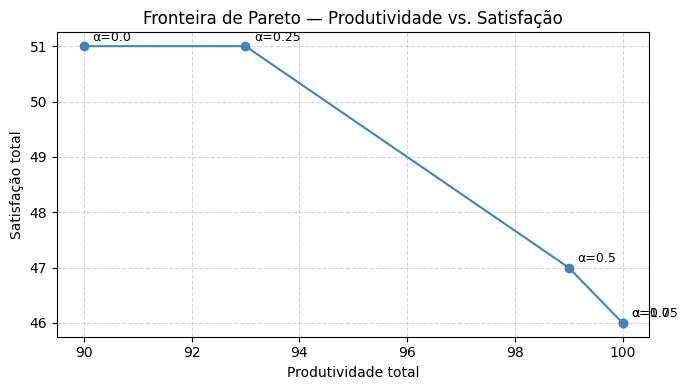

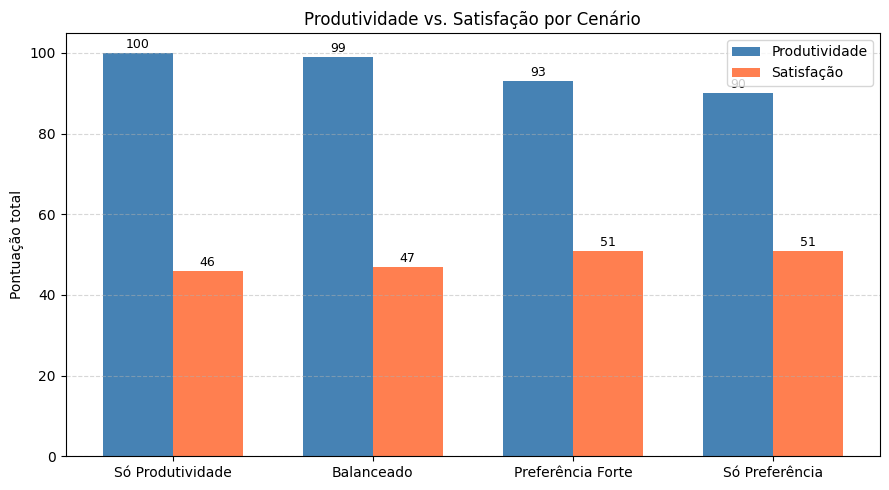

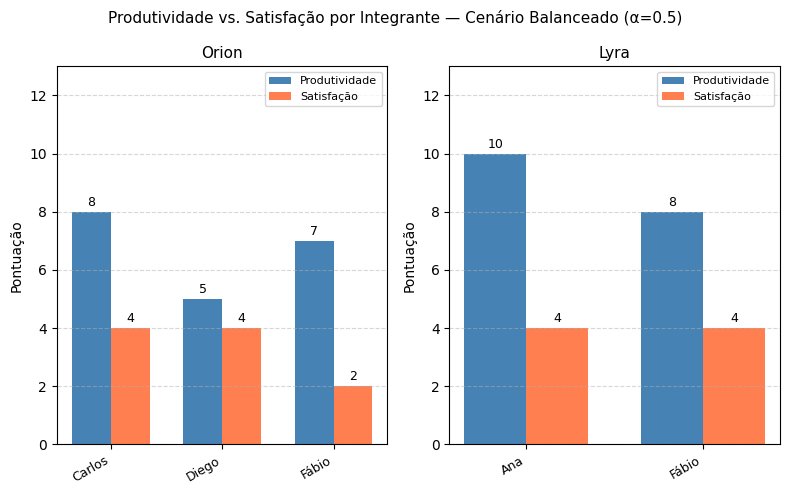

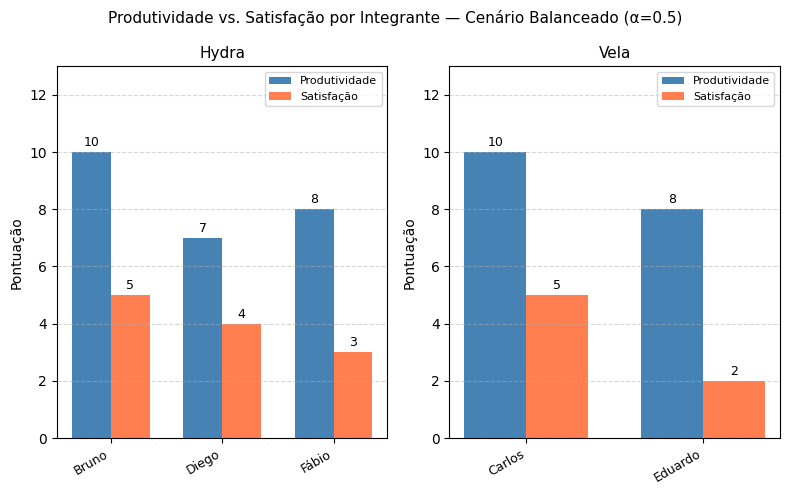

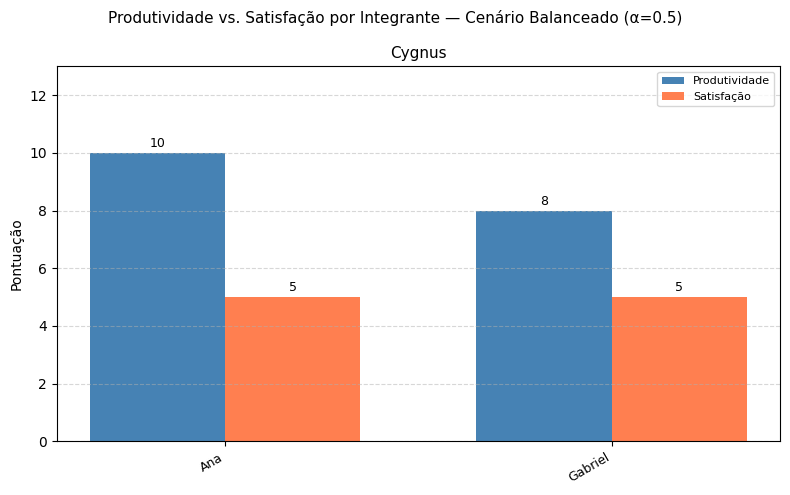

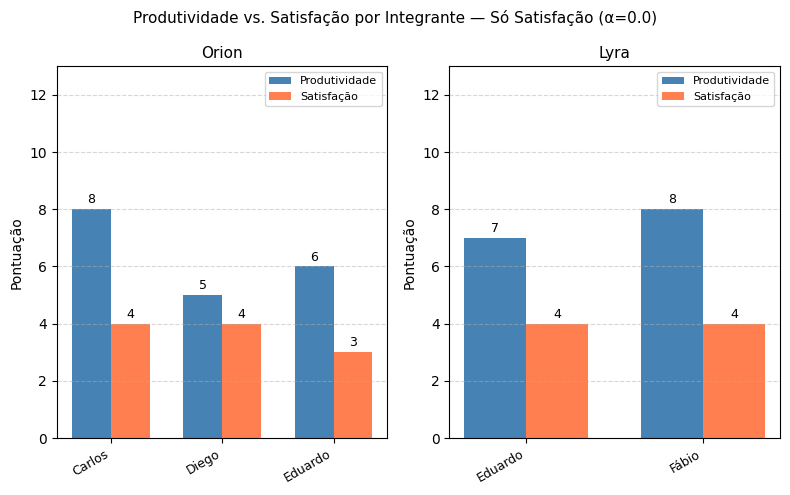

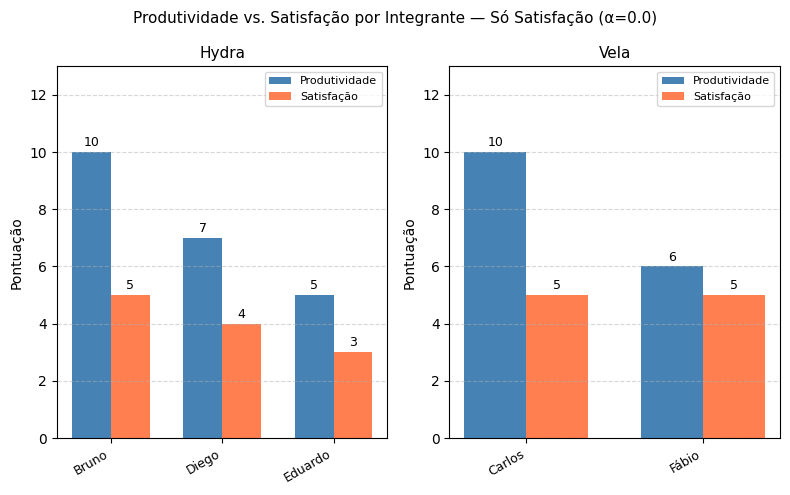

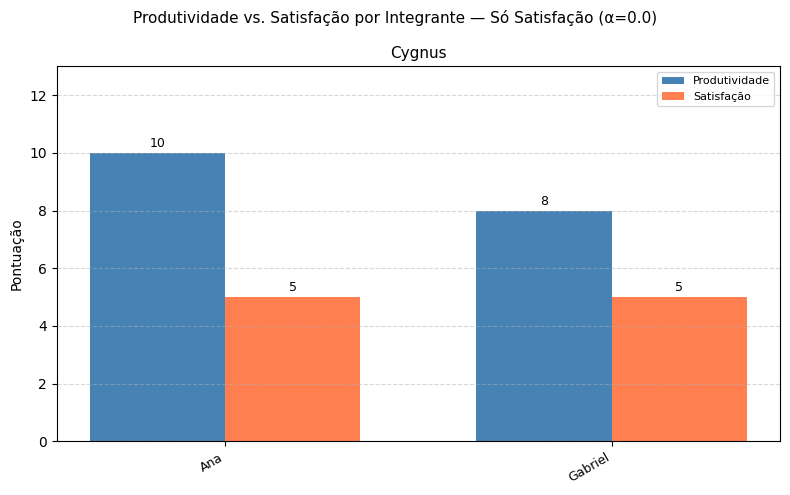


  α=0.0  |  Prod total: 90  |  Satisfação total: 51

  🔧 BAU  Orion  (3 devs | prod: 19 | sat: 11)
     🔵 Sênior  Carlos      prod: 8  sat: 4
     ⚪ Júnior  Diego       prod: 5  sat: 4
     ⚪ Júnior  Eduardo     prod: 6  sat: 3

  🔧 BAU  Lyra  (2 devs | prod: 15 | sat: 8)
     ⚪ Júnior  Eduardo     prod: 7  sat: 4
     ⚪ Júnior  Fábio       prod: 8  sat: 4

  🚀 Dev  Hydra  (3 devs | prod: 22 | sat: 12)
     🔵 Sênior  Bruno       prod: 10  sat: 5
     ⚪ Júnior  Diego       prod: 7  sat: 4
     ⚪ Júnior  Eduardo     prod: 5  sat: 3

  🚀 Dev  Vela  (2 devs | prod: 16 | sat: 10)
     🔵 Sênior  Carlos      prod: 10  sat: 5
     ⚪ Júnior  Fábio       prod: 6  sat: 5

  🚀 Dev  Cygnus  (2 devs | prod: 18 | sat: 10)
     🔵 Sênior  Ana         prod: 10  sat: 5
     ⚪ Júnior  Gabriel     prod: 8  sat: 5

  α=0.25  |  Prod total: 93  |  Satisfação total: 51

  🔧 BAU  Orion  (3 devs | prod: 19 | sat: 11)
     🔵 Sênior  Carlos      prod: 8  sat: 4
     ⚪ Júnior  Diego       prod: 5  sat: 4
     ⚪ J

In [3]:
import matplotlib.pyplot as plt

pref = {
    "Ana":     {"Orion": 1, "Lyra": 4, "Hydra": 3, "Vela": 4, "Cygnus": 5},
    "Bruno":   {"Orion": 1, "Lyra": 2, "Hydra": 5, "Vela": 3, "Cygnus": 3},
    "Carlos":  {"Orion": 4, "Lyra": 3, "Hydra": 4, "Vela": 5, "Cygnus": 3},
    "Diego":   {"Orion": 4, "Lyra": 3, "Hydra": 4, "Vela": 2, "Cygnus": 3},
    "Eduardo": {"Orion": 3, "Lyra": 4, "Hydra": 3, "Vela": 2, "Cygnus": 2},
    "Fábio":   {"Orion": 2, "Lyra": 4, "Hydra": 3, "Vela": 5, "Cygnus": 3},
    "Gabriel": {"Orion": 1, "Lyra": 3, "Hydra": 2, "Vela": 3, "Cygnus": 5},
}

def resolver_multicriterio(alpha):
    p = LpProblem("Alocacao_Multi", LpMaximize)
    xm = LpVariable.dicts("x", (devs, projetos), cat="Binary")
    p += alpha * lpSum(prod[d][p_] * xm[d][p_] for d in devs for p_ in projetos) + \
         (1 - alpha) * lpSum(pref[d][p_] * xm[d][p_] for d in devs for p_ in projetos)
    for d in devs:
        p += lpSum(xm[d][p_] for p_ in dev_proj) <= 1
    for p_ in dev_proj:
        p += lpSum(xm[s][p_] for s in seniors) >= 1
    p += lpSum(xm[d]["Hydra"] for d in devs) >= 2
    p += xm["Ana"]["Cygnus"] == 1
    for p_ in projetos:
        mn, mx = limites[p_]
        p += lpSum(xm[d][p_] for d in devs) >= mn
        p += lpSum(xm[d][p_] for d in devs) <= mx
    p.solve(PULP_CBC_CMD(msg=0))
    total_prod = sum(prod[d][p_] * value(xm[d][p_]) for d in devs for p_ in projetos)
    total_pref = sum(pref[d][p_] * value(xm[d][p_]) for d in devs for p_ in projetos)
    return total_prod, total_pref, xm

alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
resultados = [resolver_multicriterio(a) for a in alphas]

print(f"{'α':>5}  {'Produtividade':>14}  {'Satisfação':>11}")
print("-" * 35)
for a, (tp, ts, _) in zip(alphas, resultados):
    print(f"{a:>5.2f}  {tp:>14.0f}  {ts:>11.0f}")

# Fronteira de Pareto
prods = [r[0] for r in resultados]
prefs = [r[1] for r in resultados]

plt.figure(figsize=(7, 4))
plt.plot(prods, prefs, 'o-', color='steelblue')
for a, px, py in zip(alphas, prods, prefs):
    plt.annotate(f'α={a}', (px, py), textcoords='offset points', xytext=(6, 4), fontsize=9)
plt.xlabel('Produtividade total')
plt.ylabel('Satisfação total')
plt.title('Fronteira de Pareto — Produtividade vs. Satisfação')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Gráfico de barras: produtividade vs satisfação por cenário
cenarios = [
    (1.00, 'Só Produtividade'),
    (0.50, 'Balanceado'),
    (0.25, 'Preferência Forte'),
    (0.00, 'Só Preferência'),
]

titulos = [t for _, t in cenarios]
prods_c = [resultados[alphas.index(a)][0] for a, _ in cenarios]
prefs_c = [resultados[alphas.index(a)][1] for a, _ in cenarios]

x = range(len(cenarios))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_prod = ax.bar([i - width/2 for i in x], prods_c, width, label='Produtividade', color='steelblue')
bars_pref = ax.bar([i + width/2 for i in x], prefs_c, width, label='Satisfação', color='coral')
for bar in bars_prod:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
for bar in bars_pref:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(list(x))
ax.set_xticklabels(titulos, fontsize=10)
ax.set_ylabel('Pontuação total')
ax.set_title('Produtividade vs. Satisfação por Cenário')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Gráfico por projeto — cenário balanceado (alpha=0.5)
_, _, xm_bal = resultados[alphas.index(0.5)]

for i in range(0, len(projetos), 2):
    grupo = projetos[i:i+2]
    fig, axes = plt.subplots(1, len(grupo), figsize=(8, 5))
    if len(grupo) == 1:
        axes = [axes]
    for ax, p_ in zip(axes, grupo):
        alocados = [d for d in devs if value(xm_bal[d][p_]) == 1]
        prod_vals = [prod[d][p_] for d in alocados]
        pref_vals = [pref[d][p_] for d in alocados]
        x_pos = range(len(alocados))
        width = 0.35
        bars_p = ax.bar([i2 - width/2 for i2 in x_pos], prod_vals, width, label='Produtividade', color='steelblue')
        bars_s = ax.bar([i2 + width/2 for i2 in x_pos], pref_vals, width, label='Satisfação', color='coral')
        for bar in bars_p:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
        for bar in bars_s:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
        ax.set_title(p_, fontsize=11)
        ax.set_xticks(list(x_pos))
        ax.set_xticklabels(alocados, rotation=30, ha='right', fontsize=9)
        ax.set_ylim(0, 13)
        ax.set_ylabel('Pontuação')
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.legend(fontsize=8)
    fig.suptitle('Produtividade vs. Satisfação por Integrante — Cenário Balanceado (α=0.5)', fontsize=11)
    plt.tight_layout()
    plt.show()

# Gráfico por projeto — cenário só satisfação (alpha=0.0)
_, _, xm_sat = resultados[alphas.index(0.0)]

for i in range(0, len(projetos), 2):
    grupo = projetos[i:i+2]
    fig, axes = plt.subplots(1, len(grupo), figsize=(8, 5))
    if len(grupo) == 1:
        axes = [axes]
    for ax, p_ in zip(axes, grupo):
        alocados = [d for d in devs if value(xm_sat[d][p_]) == 1]
        prod_vals = [prod[d][p_] for d in alocados]
        pref_vals = [pref[d][p_] for d in alocados]
        x_pos = range(len(alocados))
        width = 0.35
        bars_p = ax.bar([i2 - width/2 for i2 in x_pos], prod_vals, width, label='Produtividade', color='steelblue')
        bars_s = ax.bar([i2 + width/2 for i2 in x_pos], pref_vals, width, label='Satisfação', color='coral')
        for bar in bars_p:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
        for bar in bars_s:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
        ax.set_title(p_, fontsize=11)
        ax.set_xticks(list(x_pos))
        ax.set_xticklabels(alocados, rotation=30, ha='right', fontsize=9)
        ax.set_ylim(0, 13)
        ax.set_ylabel('Pontuação')
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.legend(fontsize=8)
    fig.suptitle('Produtividade vs. Satisfação por Integrante — Só Satisfação (α=0.0)', fontsize=11)
    plt.tight_layout()
    plt.show()

# Detalhamento por projeto para cada alpha
for a, (tp, ts, xm) in zip(alphas, resultados):
    print(f"\n{'='*40}")
    print(f"  α={a}  |  Prod total: {tp:.0f}  |  Satisfação total: {ts:.0f}")
    print(f"{'='*40}")
    for p_ in projetos:
        alocados = [d for d in devs if value(xm[d][p_]) == 1]
        prod_proj = sum(prod[d][p_] for d in alocados)
        pref_proj = sum(pref[d][p_] for d in alocados)
        tipo = "🔧 BAU" if p_ in ["Orion", "Lyra"] else "🚀 Dev"
        print(f"\n  {tipo}  {p_}  ({len(alocados)} devs | prod: {prod_proj} | sat: {pref_proj})")
        for d in alocados:
            nivel = "🔵 Sênior" if d in seniors else "⚪ Júnior"
            print(f"     {nivel}  {d:<10}  prod: {prod[d][p_]}  sat: {pref[d][p_]}")